In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
from zoneinfo import ZoneInfo
import matplotlib.dates as mdates

plt.rcParams.update({'font.size': 14}) # Set global font size to 18
plt.rcParams["figure.figsize"] = (10, 6) 

dataset_path = "../data/dados_telemetria/mineirao_27062026/boson2"
ntc = pd.read_csv(f'{dataset_path}/73_TEMPERATURE_NTC_1.csv')
imu = pd.read_csv(f'{dataset_path}/1_GYROSCOPE.csv')
bms_stack_voltage = pd.read_csv(f'{dataset_path}/34_STACK_VOLTAGE_1.csv')
bms_glv = pd.read_csv(f'{dataset_path}/8_AIR_GVL_CURRENT.csv')
ecu_tractive = pd.read_csv(f'{dataset_path}/20_LEFT_MOTOR_TRACTIVE.csv')
gnss = pd.read_csv(f'{dataset_path}/14_GNSS_LONGITUDE.csv')

datasets_list = [
    ("ID 73 - TEMPERATURA ", pd.read_csv(f'{dataset_path}/73_TEMPERATURE_NTC_1.csv')),
    ("ID 1 - IMU ", pd.read_csv(f'{dataset_path}/1_GYROSCOPE.csv')),
    ("ID 34 - BMS STACK VOLTAGE ", pd.read_csv(f'{dataset_path}/34_STACK_VOLTAGE_1.csv')),
    ("ID 40 - BMS STACK TEMPERATURE ", pd.read_csv(f'{dataset_path}/40_STACK_TEMPERATURE_1.csv')),
    ("ID 8 - BMS AIR_GLV_SHUNT ", pd.read_csv(f'{dataset_path}/8_AIR_GVL_CURRENT.csv')),
    ("ID 20 - ECU MOTOR TRACTIVE ", pd.read_csv(f'{dataset_path}/20_LEFT_MOTOR_TRACTIVE.csv')),
    ("ID 16 - ECU DRIVER INPUTS ", pd.read_csv(f'{dataset_path}/20_LEFT_MOTOR_TRACTIVE.csv')),
    ("ID 14 - GNSS ", pd.read_csv(f'{dataset_path}/14_GNSS_LONGITUDE.csv')),
]

In [25]:
for i in range(len(datasets_list)):
    label, df = datasets_list[i]
    df["dt"] = df["date"].diff()
    df["dt"] = df[df["dt"] < 1e4]['dt']

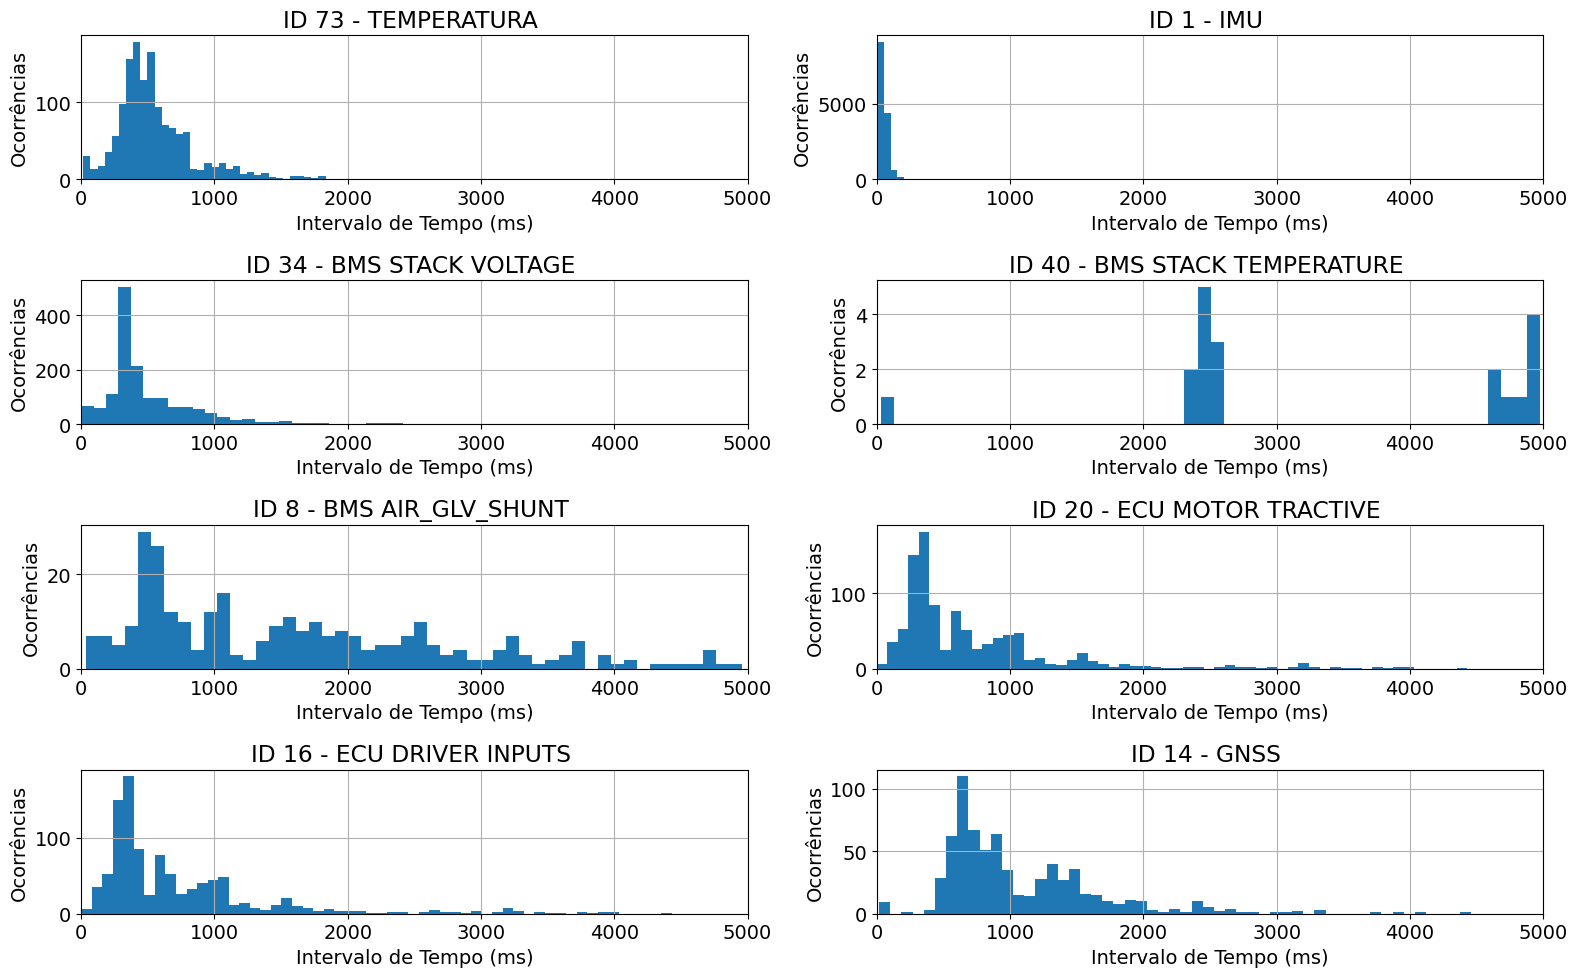

In [26]:
plt.rcParams.update({
    "font.size": 14
})

fig, axes = plt.subplots(4, 2, figsize=(16, 10))

for i, ax in enumerate(axes.flat):
    label, df = datasets_list[i]
    
    ax.hist(df["dt"].iloc[1:], bins=100)
    ax.set_title(label)
    ax.set_xlabel('Intervalo de Tempo (ms)')
    ax.set_ylabel('Ocorrências')
    ax.set_xlim(0, 5000)
    # ax.set_ylim(1, 1e4)
    ax.grid()

plt.tight_layout()
plt.show()